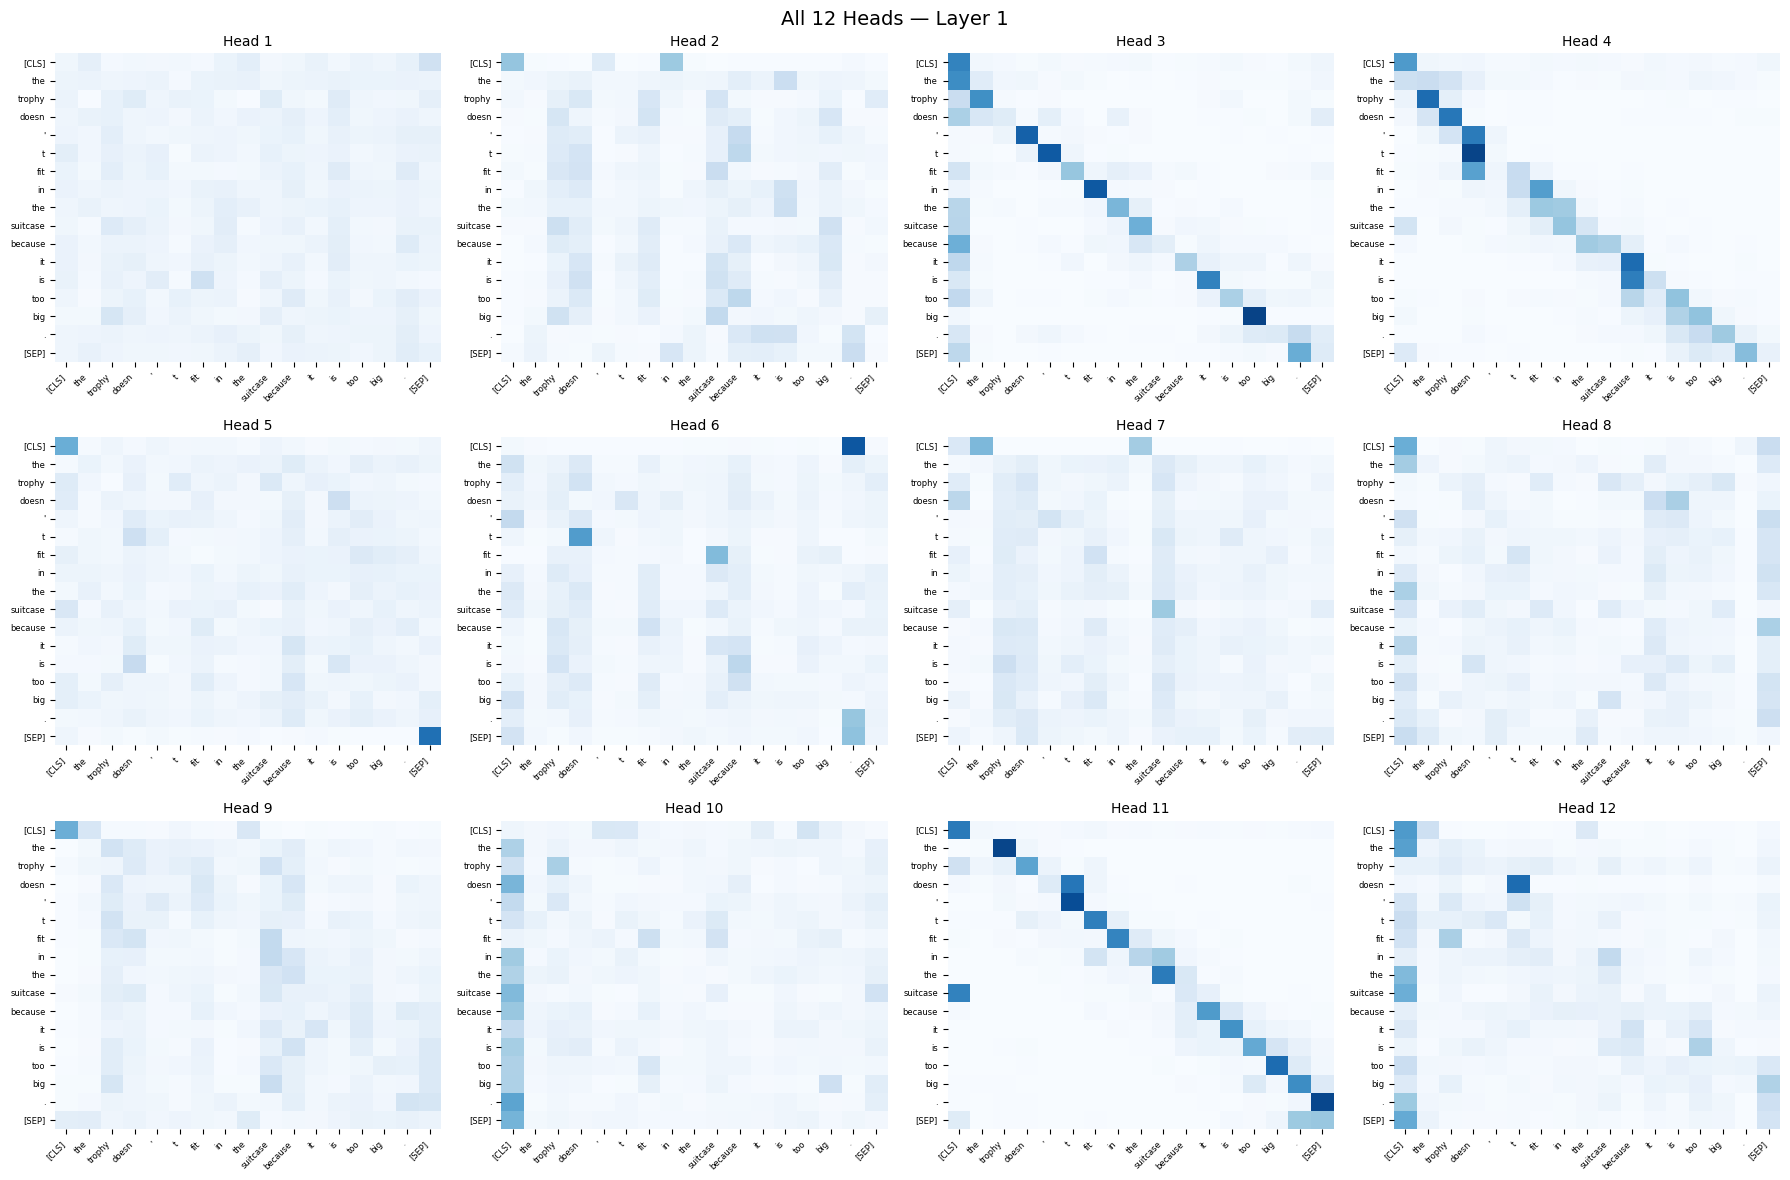

In [2]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
model.eval()

sentence = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

layer = 0
heads = outputs.attentions[layer][0]  # shape: (12, seq_len, seq_len)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for head in range(12):
    attn = heads[head].numpy()
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
                cmap="Blues", vmin=0, vmax=1,
                ax=axes[head], cbar=False)
    axes[head].set_title(f"Head {head+1}", fontsize=10)
    axes[head].tick_params(labelsize=6)
    axes[head].set_xticklabels(tokens, rotation=45, ha="right")

fig.suptitle(f"All 12 Heads — Layer {layer+1}", fontsize=14)
plt.tight_layout()
plt.show()